In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split # Tạm dùng để tách validation/test
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

In [2]:
CSV_FILE = ["/home/stock-agent/ml/stock_models/data/GOOGL_1year_monthly.csv",
            "/home/stock-agent/ml/stock_models/data/MSFT_1year_monthly.csv",
            "/home/stock-agent/ml/stock_models/data/NVDA_1year_monthly.csv"] # File CSV đã tạo từ bước trước
FEATURES = ['Open', 'High', 'Low', 'Close', 'Volume'] # Các đặc trưng sử dụng
TARGET = 'Target'
SEQUENCE_LENGTH = 6 # Sử dụng dữ liệu 6 tháng trước để dự đoán
BATCH_SIZE = 16 # Kích thước lô
HIDDEN_SIZE = 64 # Số units trong lớp LSTM
NUM_LAYERS = 2    # Số lớp LSTM chồng lên nhau
LEARNING_RATE = 0.001
EPOCHS = 100
TEST_SIZE = 0.15 # Tỷ lệ dữ liệu cho tập test
VALID_SIZE = 0.15 # Tỷ lệ dữ liệu (của phần còn lại sau test) cho tập validation
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
from tensorflow.keras.models import load_model
import joblib

scaler = joblib.load("./models/scaler.save")
# Load lại model
model = load_model("./models/best_model.h5")

# Kiểm tra kiến trúc
model.summary()

2025-05-09 16:11:52.982636: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-09 16:11:52.985890: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-09 16:11:52.996418: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746807113.013896  206505 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746807113.019460  206505 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746807113.033133  206505 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 6, 128)         │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,083 (461.27 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [11]:

csv_file = CSV_FILE[1]
df_all = pd.read_csv(csv_file, parse_dates=['Date'])
df_all.sort_values(by=['Date'], inplace=True)
data = df_all.filter(['Close'])
# Convert the dataframe to a numpy array
dataset = data.values
training_data_len = int(np.ceil( len(dataset) * .95 ))
scaled_data = scaler.transform(dataset)
test_data = scaled_data[training_data_len - SEQUENCE_LENGTH: , :]
print(len(test_data))
# Create the data sets x_test and y_test
x_test = []
y_test = dataset[training_data_len:, :]
for i in range(SEQUENCE_LENGTH, len(test_data)):
    x_test.append(test_data[i-SEQUENCE_LENGTH:i, 0])
    
# Convert the data to a numpy array
x_test = np.array(x_test)

# Reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))
# Get the models predicted price values 
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# Get the root mean squared error (RMSE)
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
rmse

21
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


23.14720193138393

In [12]:
predictions = np.array(predictions)
bi_preds = predictions.reshape(-1)
bi_ground_truth = y_test.reshape(-1)
bi_pred = (bi_preds[1:] > bi_preds[:-1]).astype(int)
bi_gt = (bi_ground_truth[1:] > bi_ground_truth[:-1]).astype(int)
accuracy = np.sum(bi_pred == bi_gt)
print(len(bi_pred))
accuracy

14


5

/tmp/ipykernel_206505/3344400724.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


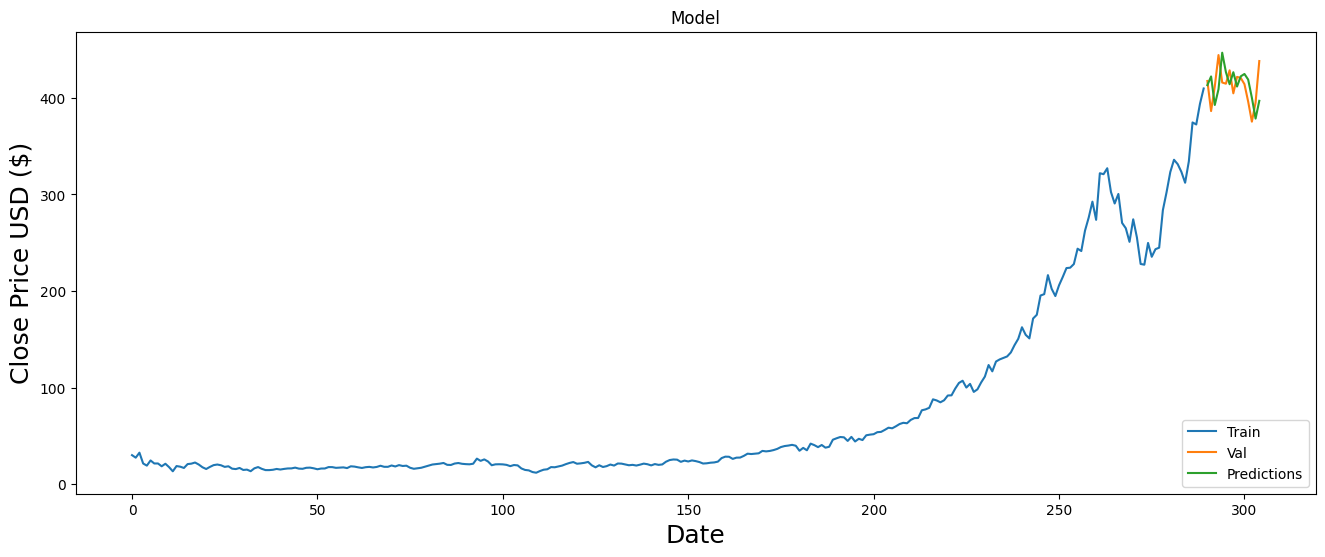

In [13]:
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions
# Visualize the data
plt.figure(figsize=(16,6))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()